# Chart Gallery

Starter notebook for loading data and creating common chart types.

In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

from visualizer import load_csv, save_figure, set_chart_style

set_chart_style()

## Load Sample Data

In [4]:
data_path = PROJECT_ROOT / "data" / "raw" / "sample_sales.csv"
df = load_csv(data_path, parse_dates=["date"])
df.head()

,date,region,product,units,revenue,customer_satisfaction
0,2026-01-01,North,Alpha,42,4200,8.4
1,2026-01-02,North,Beta,35,3150,8.0
2,2026-01-03,South,Alpha,28,2940,7.7
3,2026-01-04,South,Gamma,51,6120,8.9
4,2026-01-05,East,Beta,46,4140,8.2


## Revenue Over Time

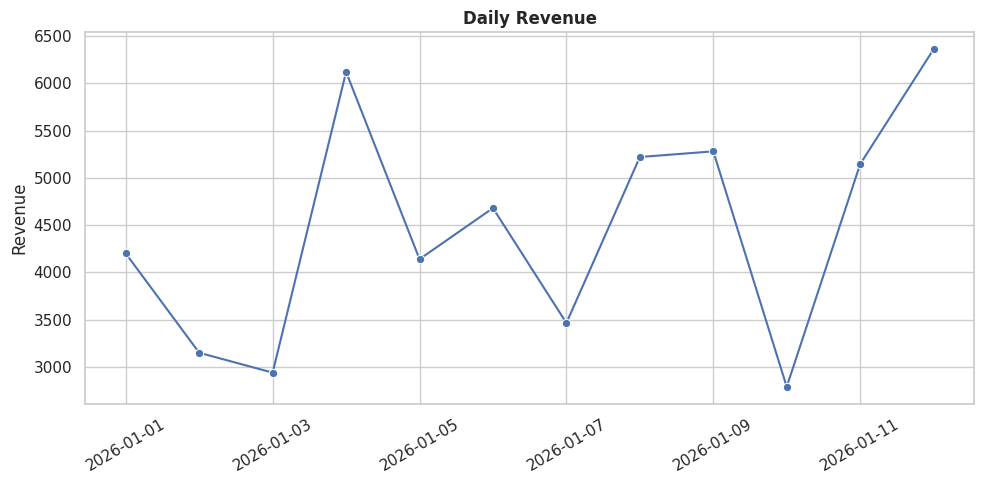

In [5]:
daily_revenue = df.groupby("date", as_index=False)["revenue"].sum()

ax = sns.lineplot(data=daily_revenue, x="date", y="revenue", marker="o")
ax.set_title("Daily Revenue")
ax.set_xlabel("")
ax.set_ylabel("Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
save_figure("daily_revenue.png", PROJECT_ROOT / "outputs" / "figures")
plt.show()

## Revenue By Region

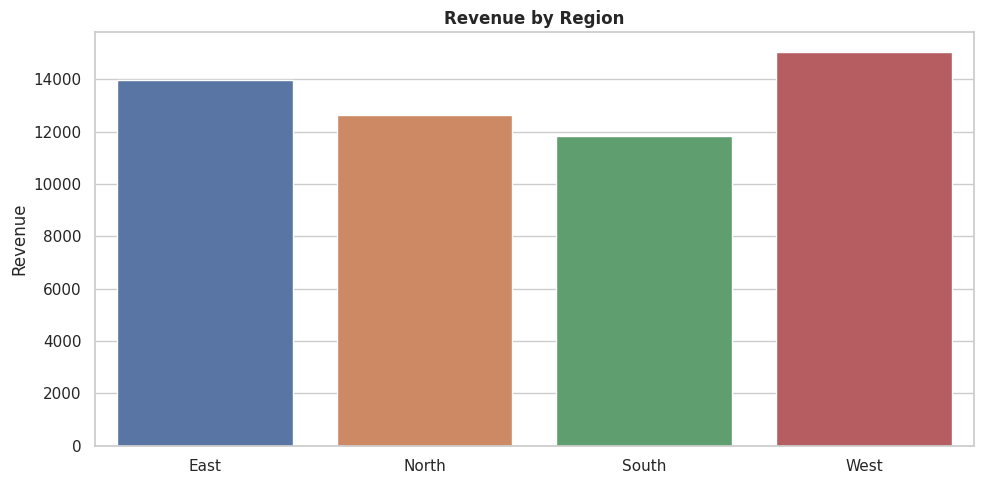

In [6]:
region_revenue = df.groupby("region", as_index=False)["revenue"].sum()

ax = sns.barplot(data=region_revenue, x="region", y="revenue", hue="region", legend=False)
ax.set_title("Revenue by Region")
ax.set_xlabel("")
ax.set_ylabel("Revenue")
plt.tight_layout()
plt.show()

## Units vs Revenue

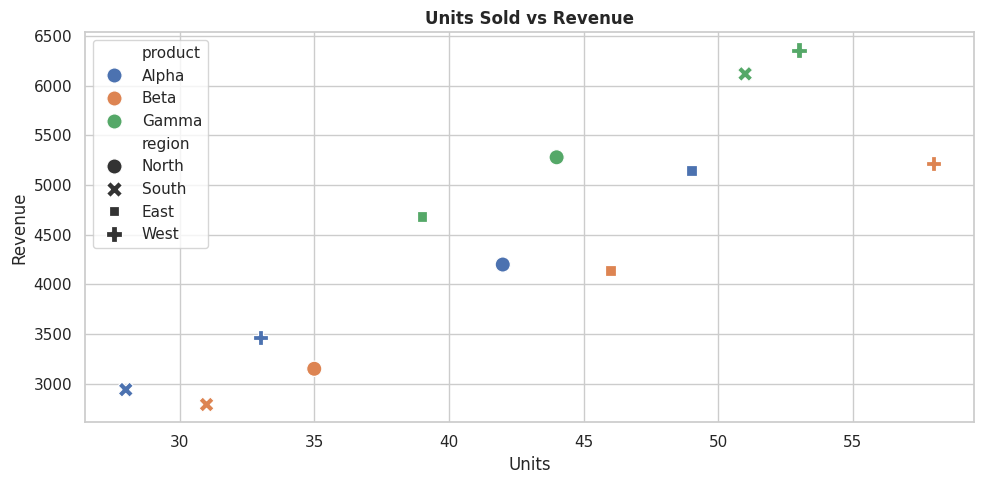

In [7]:
ax = sns.scatterplot(data=df, x="units", y="revenue", hue="product", style="region", s=120)
ax.set_title("Units Sold vs Revenue")
ax.set_xlabel("Units")
ax.set_ylabel("Revenue")
plt.tight_layout()
plt.show()

## Product and Region Heatmap

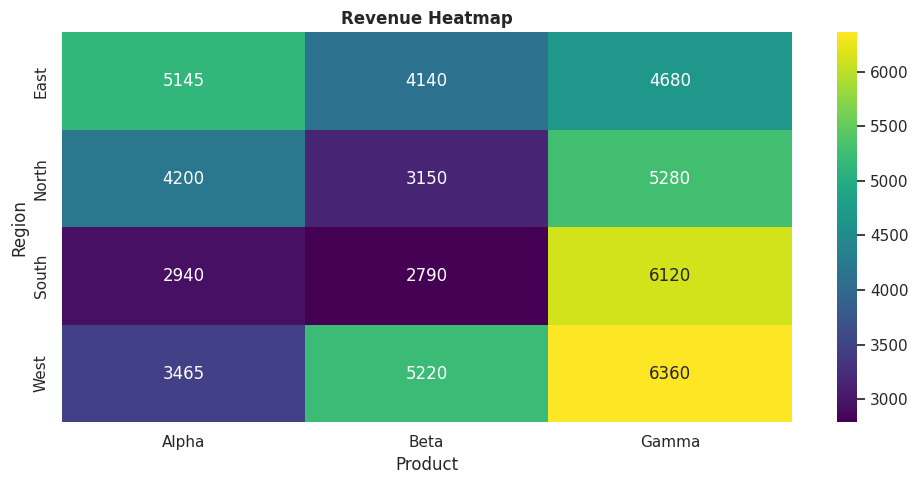

In [8]:
heatmap_data = df.pivot_table(index="region", columns="product", values="revenue", aggfunc="sum")

ax = sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="viridis")
ax.set_title("Revenue Heatmap")
ax.set_xlabel("Product")
ax.set_ylabel("Region")
plt.tight_layout()
plt.show()

## Interactive Plotly Chart

In [9]:
fig = px.line(
    df.sort_values("date"),
    x="date",
    y="revenue",
    color="region",
    markers=True,
    title="Interactive Revenue Trend",
)
fig.show()